In [15]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

In [16]:
# -----------------------------
# 1. Create dummy data
# -----------------------------
np.random.seed(42)

n = 200

X = pd.DataFrame({
    "size_m2": np.random.uniform(50, 250, n),
    "bedrooms": np.random.randint(1, 6, n),
    "age_years": np.random.uniform(0, 30, n)
})

# House price (€)
y = (
    1500 * X["size_m2"]
    + 20000 * X["bedrooms"]
    - 1000 * X["age_years"]
    + np.random.normal(0, 30000, n)
)

In [17]:

# -----------------------------
# 2. Split into train/calibration
# -----------------------------
X_train = X.iloc[:140]
y_train = y.iloc[:140]

X_cal = X.iloc[140:180]
y_cal = y.iloc[140:180]

X_test = X.iloc[180:]
y_test = y.iloc[180:]

# -----------------------------
# 3. Train XGBoost
# -----------------------------
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 4. Calculate calibration errors
# -----------------------------
cal_pred = model.predict(X_cal)

errors = np.abs(y_cal - cal_pred)

# 90% prediction interval
q = np.quantile(errors, 0.85)

# -----------------------------
# 5. Make predictions
# -----------------------------
pred = model.predict(X_test)

lower = pred - q
upper = pred + q

# -----------------------------
# 6. Display results
# -----------------------------
results = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": pred,
    "Lower_99": lower,
    "Upper_99": upper
})

print(results.round(0))

      Actual  Prediction  Lower_99  Upper_99
0   293544.0    263927.0  218744.0  309109.0
1   167227.0    154496.0  109314.0  199678.0
2   385198.0    381389.0  336207.0  426571.0
3   301268.0    325366.0  280183.0  370548.0
4   290150.0    231463.0  186281.0  276645.0
5   311306.0    308313.0  263131.0  353495.0
6   386891.0    401519.0  356337.0  446701.0
7   326505.0    392382.0  347200.0  437565.0
8   262026.0    207809.0  162627.0  252991.0
9   202168.0    197768.0  152586.0  242950.0
10  155196.0    177668.0  132486.0  222850.0
11  377445.0    390231.0  345048.0  435413.0
12  398932.0    369735.0  324552.0  414917.0
13  386684.0    333093.0  287911.0  378275.0
14  263382.0    187284.0  142102.0  232467.0
15  218037.0    209888.0  164706.0  255070.0
16  359007.0    367325.0  322142.0  412507.0
17  419923.0    381268.0  336085.0  426450.0
18  392280.0    354984.0  309802.0  400166.0
19  344091.0    294495.0  249313.0  339677.0


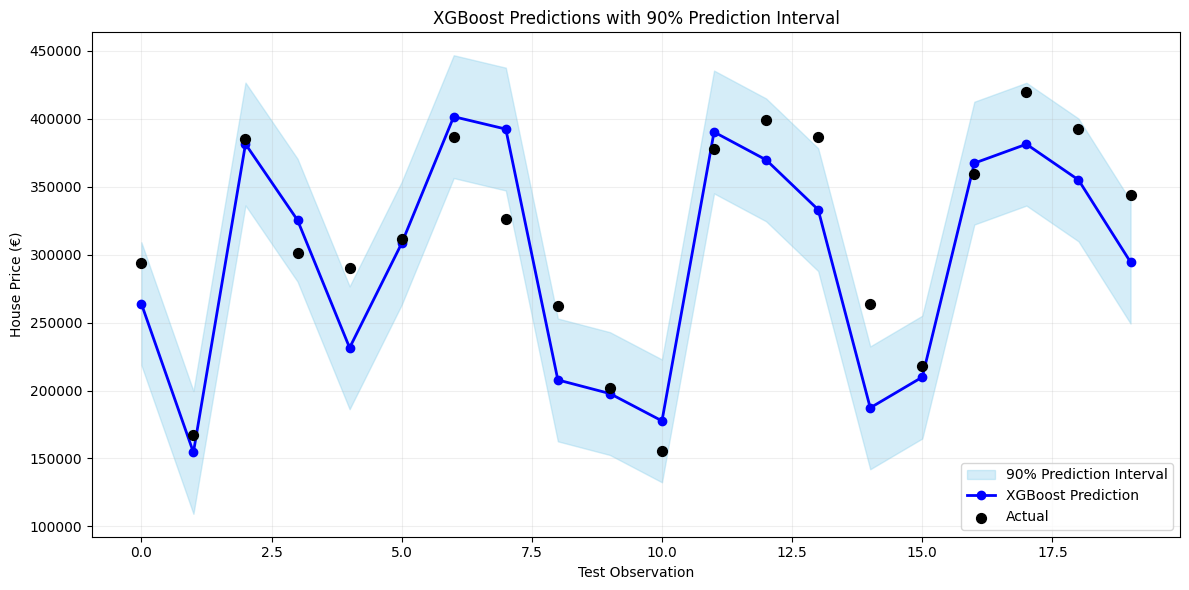

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Test observation numbers
x = np.arange(len(y_test))

plt.figure(figsize=(12, 6))

# 90% prediction interval
plt.fill_between(
    x,
    lower,
    upper,
    color="skyblue",
    alpha=0.35,
    label="90% Prediction Interval"
)

# XGBoost prediction
plt.plot(
    x,
    pred,
    color="blue",
    linewidth=2,
    marker="o",
    label="XGBoost Prediction"
)

# Actual values
plt.scatter(
    x,
    y_test,
    color="black",
    s=50,
    zorder=3,
    label="Actual"
)

plt.xlabel("Test Observation")
plt.ylabel("House Price (€)")
plt.title("XGBoost Predictions with 90% Prediction Interval")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
